In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [24]:
EPL=pd.read_csv("C:/Users/LENOVO/Downloads/final_matches.csv")
display(EPL)

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,match report,notes,sh,sot,dist,fk,pk,pkatt,team,season
0,9/12/2020,12:30,Premier League,Matchweek 1,Sat,Away,W,3,0,Fulham,...,Match Report,NaN,13,5,14.1,2,0,0,Arsenal,2021
1,9/19/2020,20:00,Premier League,Matchweek 2,Sat,Home,W,2,1,West Ham,...,Match Report,NaN,7,3,14.8,0,0,0,Arsenal,2021
2,9/28/2020,20:00,Premier League,Matchweek 3,Mon,Away,L,1,3,Liverpool,...,Match Report,NaN,4,3,15.0,0,0,0,Arsenal,2021
3,10/4/2020,14:00,Premier League,Matchweek 4,Sun,Home,W,2,1,Sheffield Utd,...,Match Report,NaN,6,5,16.3,0,0,0,Arsenal,2021
4,10/17/2020,17:30,Premier League,Matchweek 5,Sat,Away,L,0,1,Manchester City,...,Match Report,NaN,11,3,18.4,2,0,0,Arsenal,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,4/26/2025,15:00,Premier League,Matchweek 34,Sat,Home,W,3,0,Leicester City,...,Match Report,NaN,20,5,19.8,1,0,0,Wolverhampton Wanderers,2025
3796,5/2/2025,20:00,Premier League,Matchweek 35,Fri,Away,L,0,1,Manchester City,...,Match Report,NaN,6,0,16.3,0,0,0,Wolverhampton Wanderers,2025
3797,5/10/2025,15:00,Premier League,Matchweek 36,Sat,Home,L,0,2,Brighton,...,Match Report,NaN,10,3,15.5,0,0,0,Wolverhampton Wanderers,2025
3798,5/20/2025,20:00,Premier League,Matchweek 37,Tue,Away,L,2,4,Crystal Palace,...,Match Report,NaN,12,3,15.1,0,0,0,Wolverhampton Wanderers,2025


In [25]:
# cleaning and sorting the data
EPL24_25=EPL[EPL['season']==2025].copy().reset_index(drop=True)
EPL24_25.drop(['notes'],axis=1,inplace=True)
display(EPL24_25)
print('Shape:', EPL24_25.shape)
print('\nUnique teams:', EPL24_25['team'].nunique())
print('\nSample rounds:', EPL24_25['round'].unique()[:5])
print('\nResult values:', EPL24_25['result'].unique())

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,referee,match report,sh,sot,dist,fk,pk,pkatt,team,season
0,8/17/2024,15:00,Premier League,Matchweek 1,Sat,Home,W,2,0,Wolves,...,Jarred Gillett,Match Report,18,6,17.3,0,0,0,Arsenal,2025
1,8/24/2024,17:30,Premier League,Matchweek 2,Sat,Away,W,2,0,Aston Villa,...,Michael Oliver,Match Report,9,4,18.8,0,0,0,Arsenal,2025
2,8/31/2024,12:30,Premier League,Matchweek 3,Sat,Home,D,1,1,Brighton,...,Chris Kavanagh,Match Report,11,7,12.9,0,0,0,Arsenal,2025
3,9/15/2024,14:00,Premier League,Matchweek 4,Sun,Away,W,1,0,Tottenham,...,Jarred Gillett,Match Report,7,4,12.1,0,0,0,Arsenal,2025
4,9/22/2024,16:30,Premier League,Matchweek 5,Sun,Away,D,2,2,Manchester City,...,Michael Oliver,Match Report,5,3,11.3,0,0,0,Arsenal,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,4/26/2025,15:00,Premier League,Matchweek 34,Sat,Home,W,3,0,Leicester City,...,Samuel Barrott,Match Report,20,5,19.8,1,0,0,Wolverhampton Wanderers,2025
756,5/2/2025,20:00,Premier League,Matchweek 35,Fri,Away,L,0,1,Manchester City,...,Peter Bankes,Match Report,6,0,16.3,0,0,0,Wolverhampton Wanderers,2025
757,5/10/2025,15:00,Premier League,Matchweek 36,Sat,Home,L,0,2,Brighton,...,Michael Oliver,Match Report,10,3,15.5,0,0,0,Wolverhampton Wanderers,2025
758,5/20/2025,20:00,Premier League,Matchweek 37,Tue,Away,L,2,4,Crystal Palace,...,David Webb,Match Report,12,3,15.1,0,0,0,Wolverhampton Wanderers,2025


Shape: (760, 27)

Unique teams: 20

Sample rounds: ['Matchweek 1' 'Matchweek 2' 'Matchweek 3' 'Matchweek 4' 'Matchweek 5']

Result values: ['W' 'D' 'L']


In [28]:
# calculating the result
def get_points(result):
    if result=="W":
        return 3
    elif result=="D":
        return 1
    else:
        return 0
EPL24_25['points']=EPL24_25['result'].apply(get_points)
EPL24_25['matchweek'] = EPL24_25['round'].str.extract('(\d+)').astype(int)
print(EPL24_25[['team', 'round', 'matchweek','result', 'points']].head(10))

      team         round  matchweek result  points
0  Arsenal   Matchweek 1          1      W       3
1  Arsenal   Matchweek 2          2      W       3
2  Arsenal   Matchweek 3          3      D       1
3  Arsenal   Matchweek 4          4      W       3
4  Arsenal   Matchweek 5          5      D       1
5  Arsenal   Matchweek 6          6      W       3
6  Arsenal   Matchweek 7          7      W       3
7  Arsenal   Matchweek 8          8      L       0
8  Arsenal   Matchweek 9          9      D       1
9  Arsenal  Matchweek 10         10      L       0


In [46]:
# top 6 teams
top6=['Liverpool','Manchester United','Manchester City','Arsenal','Chelsea','Tottenham Hotspur']
EPL24_25_top6=EPL24_25[EPL24_25['team'].isin(top6)].copy().reset_index(drop=True)
EPL24_25_top6=EPL24_25_top6.sort_values(['team','matchweek']).reset_index(drop=True)
EPL24_25_top6['cumulative_points']=EPL24_25_top6.groupby('team')['points'].cumsum()
display(EPL24_25_top6)
print(EPL24_25_top6[['team', 'matchweek', 'result', 'points', 'cumulative_points']].head(15))

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,sot,dist,fk,pk,pkatt,team,season,points,matchweek,cumulative_points
0,8/17/2024,15:00,Premier League,Matchweek 1,Sat,Home,W,2,0,Wolves,...,6,17.3,0,0,0,Arsenal,2025,3,1,3
1,8/24/2024,17:30,Premier League,Matchweek 2,Sat,Away,W,2,0,Aston Villa,...,4,18.8,0,0,0,Arsenal,2025,3,2,6
2,8/31/2024,12:30,Premier League,Matchweek 3,Sat,Home,D,1,1,Brighton,...,7,12.9,0,0,0,Arsenal,2025,1,3,7
3,9/15/2024,14:00,Premier League,Matchweek 4,Sun,Away,W,1,0,Tottenham,...,4,12.1,0,0,0,Arsenal,2025,3,4,10
4,9/22/2024,16:30,Premier League,Matchweek 5,Sun,Away,D,2,2,Manchester City,...,3,11.3,0,0,0,Arsenal,2025,1,5,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,4/27/2025,16:30,Premier League,Matchweek 34,Sun,Away,L,1,5,Liverpool,...,3,20.4,0,0,0,Tottenham Hotspur,2025,0,34,37
224,5/4/2025,14:00,Premier League,Matchweek 35,Sun,Away,D,1,1,West Ham,...,2,18.8,1,0,0,Tottenham Hotspur,2025,1,35,38
225,5/11/2025,14:15,Premier League,Matchweek 36,Sun,Home,L,0,2,Crystal Palace,...,1,15.1,1,0,0,Tottenham Hotspur,2025,0,36,38
226,5/16/2025,19:30,Premier League,Matchweek 37,Fri,Away,L,0,2,Aston Villa,...,1,17.0,1,0,0,Tottenham Hotspur,2025,0,37,38


       team  matchweek result  points  cumulative_points
0   Arsenal          1      W       3                  3
1   Arsenal          2      W       3                  6
2   Arsenal          3      D       1                  7
3   Arsenal          4      W       3                 10
4   Arsenal          5      D       1                 11
5   Arsenal          6      W       3                 14
6   Arsenal          7      W       3                 17
7   Arsenal          8      L       0                 17
8   Arsenal          9      D       1                 18
9   Arsenal         10      L       0                 18
10  Arsenal         11      D       1                 19
11  Arsenal         12      W       3                 22
12  Arsenal         13      W       3                 25
13  Arsenal         14      W       3                 28
14  Arsenal         15      D       1                 29


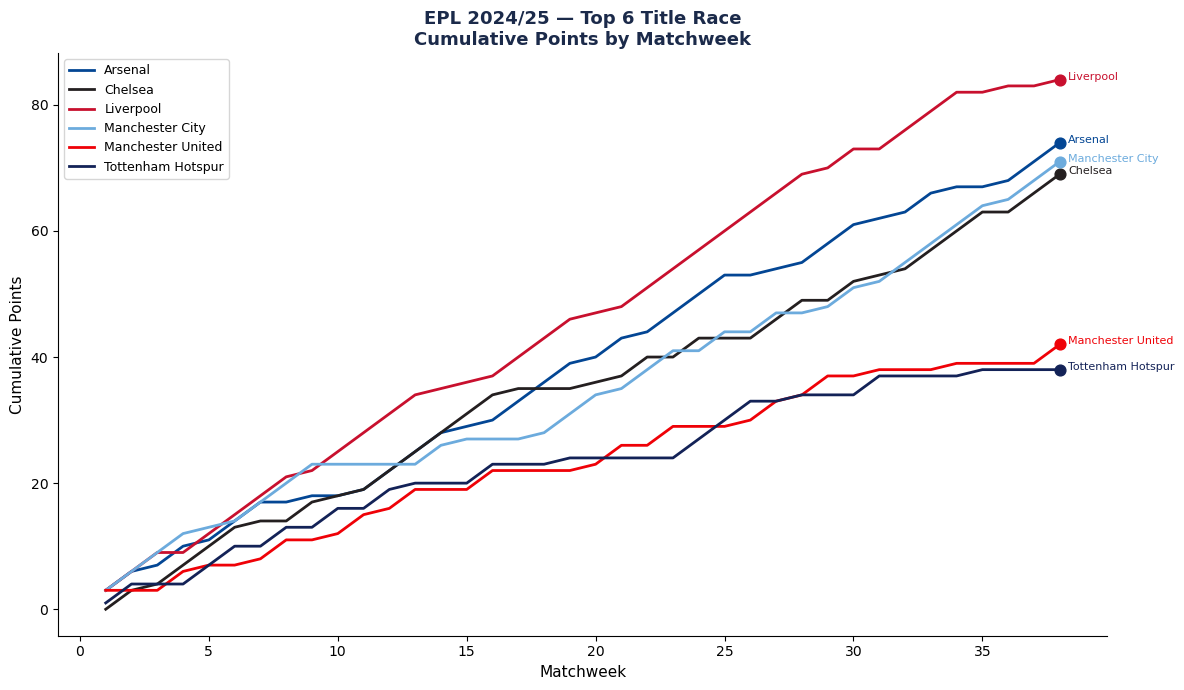

In [48]:
# chart
colors = {
    'Liverpool': '#C8102E',
    'Manchester United': '#EF0107',
    'Arsenal': '#034694',
    'Manchester City': '#6CABDD',
    'Chelsea': '#241F20',
    'Tottenham Hotspur': '#132257'
}
fig, ax = plt.subplots(figsize=(12, 7))
for team, data in EPL24_25_top6.groupby('team'):
    data = data.sort_values('matchweek')
    ax.plot(data['matchweek'], data['cumulative_points'],
        color=colors[team], linewidth=2, label=team)
    ax.scatter(data['matchweek'].iloc[-1], 
           data['cumulative_points'].iloc[-1],
           color=colors[team], s=60, zorder=5)
    ax.annotate(team,
            (data['matchweek'].iloc[-1], data['cumulative_points'].iloc[-1]),
            textcoords='offset points',
            xytext=(6, 0),
            fontsize=8,
            color=colors[team])

ax.set_xlabel('Matchweek', fontsize=11)
ax.set_ylabel('Cumulative Points', fontsize=11)
ax.set_title('EPL 2024/25 — Top 6 Title Race\nCumulative Points by Matchweek',
             fontsize=13, fontweight='bold', color='#1B2A4A')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/LENOVO/Downloads/epl_title_race_2024_25.png', dpi=150, bbox_inches='tight')
plt.show()
    